<a href="https://colab.research.google.com/github/Jigyasa-2606/Book-Recommendation-System/blob/main/ffanet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2
import os
import sys
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.utils import save_image
import torch.nn as nn
from torch.utils.data import DataLoader


In [2]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [4]:
torch.cuda.empty_cache()

In [7]:
import cv2
import os

video_path = "/content/Highway_5_fog.mp4"
cap = cv2.VideoCapture(video_path)


total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

train_end = int(0.7 * total_frames)
val_end = int(0.85 * total_frames)


base_path = "/content/dataset"

splits = ["train", "val", "test"]
for split in splits:
    os.makedirs(f"{base_path}/{split}/fog", exist_ok=True)

count = 0
saved = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break


    if count % 5 != 0:
        count += 1
        continue


    frame = cv2.resize(frame, (256, 256))

    filename = f"frame_{saved:05d}.jpg"

    if count < train_end:
        path = f"{base_path}/train/fog/{filename}"
    elif count < val_end:
        path = f"{base_path}/val/fog/{filename}"
    else:
        path = f"{base_path}/test/fog/{filename}"

    cv2.imwrite(path, frame)

    saved += 1
    count += 1

cap.release()

print(saved, "frames extracted and split")

1126 frames extracted and split


In [8]:
import cv2
import os

video_path = "/content/Highway_5_RGB.mp4"
cap = cv2.VideoCapture(video_path)


total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

train_end = int(0.7 * total_frames)
val_end = int(0.85 * total_frames)


base_path = "/content/dataset"

splits = ["train", "val", "test"]
for split in splits:
    os.makedirs(f"{base_path}/{split}/clear", exist_ok=True)

count = 0
saved = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break


    if count % 5 != 0:
        count += 1
        continue


    frame = cv2.resize(frame, (256, 256))

    filename = f"frame_{saved:05d}.jpg"

    if count < train_end:
        path = f"{base_path}/train/clear/{filename}"
    elif count < val_end:
        path = f"{base_path}/val/clear/{filename}"
    else:
        path = f"{base_path}/test/clear/{filename}"

    cv2.imwrite(path, frame)

    saved += 1
    count += 1

cap.release()

print(saved, "frames extracted and split")

1126 frames extracted and split


In [9]:
from torch.utils.data import Dataset
import os
import cv2

class DehazeDataset(Dataset):
    def __init__(self, fog_dir, clear_dir, transform=None):
        self.fog_dir = fog_dir
        self.clear_dir = clear_dir
        self.images = sorted(os.listdir(fog_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
      name = self.images[idx]
      fog = cv2.imread(os.path.join(self.fog_dir, name))
      clear = cv2.imread(os.path.join(self.clear_dir, name))


      fog = cv2.cvtColor(fog, cv2.COLOR_BGR2RGB)
      clear = cv2.cvtColor(clear, cv2.COLOR_BGR2RGB)
      fog = torch.from_numpy(fog).permute(2, 0, 1).float() / 255.0
      clear = torch.from_numpy(clear).permute(2, 0, 1).float() / 255.0

      return fog, clear

In [10]:
import os, shutil, random

base = "/content/dataset"

train_fog = f"{base}/train/fog"
train_clear = f"{base}/train/clear"

val_fog = f"{base}/val/fog"
val_clear = f"{base}/val/clear"

test_fog = f"{base}/test/fog"
test_clear = f"{base}/test/clear"

exp_base = f"{base}/experiment"

os.makedirs(f"{exp_base}/train/fog", exist_ok=True)
os.makedirs(f"{exp_base}/train/clear", exist_ok=True)

os.makedirs(f"{exp_base}/val/fog", exist_ok=True)
os.makedirs(f"{exp_base}/val/clear", exist_ok=True)

os.makedirs(f"{exp_base}/test/fog", exist_ok=True)
os.makedirs(f"{exp_base}/test/clear", exist_ok=True)

images = sorted(os.listdir(train_fog))
random.shuffle(images)

train_imgs = images[:100]
val_imgs = images[100:110]
test_imgs = images[110:112]


def copy_files(img_list, src_fog, src_clear, dst_fog, dst_clear):
  for img in img_list:
    shutil.copy(os.path.join(src_fog, img), os.path.join(dst_fog, img))
    shutil.copy(os.path.join(src_clear, img), os.path.join(dst_clear, img))

copy_files(train_imgs, train_fog, train_clear,
        f"{exp_base}/train/fog", f"{exp_base}/train/clear")

copy_files(val_imgs, train_fog, train_clear,
        f"{exp_base}/val/fog", f"{exp_base}/val/clear")

copy_files(test_imgs, train_fog, train_clear,
        f"{exp_base}/test/fog", f"{exp_base}/test/clear")

print("Experiment dataset created")

Experiment dataset created


In [11]:
!git clone https://github.com/zhilin007/FFA-Net

Cloning into 'FFA-Net'...
remote: Enumerating objects: 188, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 188 (delta 1), reused 6 (delta 1), pack-reused 182 (from 1)
Receiving objects: 100% (188/188), 19.04 MiB | 18.70 MiB/s, done.
Resolving deltas: 100% (81/81), done.


In [12]:
!find /content/FFA-Net -name "FFA.py"

/content/FFA-Net/net/models/FFA.py


In [13]:
import sys
sys.path.append('/content/FFA-Net/net/models')

from FFA import FFA   # ✅ THIS LINE YOU MISSED

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FFA(gps=3, blocks=19).to(device)

checkpoint = torch.load(
    "/content/ots_train_ffa_3_19.pk",
    map_location=device,
    weights_only=False
)

state_dict = checkpoint['model']

new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('module.'):
        new_state_dict[k[7:]] = v   # ✅ fixed indentation + line
    else:
        new_state_dict[k] = v

model.load_state_dict(new_state_dict)
model.eval()

FFA(
  (g1): Group(
    (gp): Sequential(
      (0): Block(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act1): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (calayer): CALayer(
          (avg_pool): AdaptiveAvgPool2d(output_size=1)
          (ca): Sequential(
            (0): Conv2d(64, 8, kernel_size=(1, 1), stride=(1, 1))
            (1): ReLU(inplace=True)
            (2): Conv2d(8, 64, kernel_size=(1, 1), stride=(1, 1))
            (3): Sigmoid()
          )
        )
        (palayer): PALayer(
          (pa): Sequential(
            (0): Conv2d(64, 8, kernel_size=(1, 1), stride=(1, 1))
            (1): ReLU(inplace=True)
            (2): Conv2d(8, 1, kernel_size=(1, 1), stride=(1, 1))
            (3): Sigmoid()
          )
        )
      )
      (1): Block(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act1): ReLU(inplace=T

In [17]:
from torch.utils.data import DataLoader

test_dataset = DehazeDataset(
    "/content/dataset/test/fog",
    "/content/dataset/test/clear"
)

test_loader = DataLoader(test_dataset, batch_size=1)

In [18]:
from torchvision.utils import save_image
import os

output_dir = "/content/outputs/ffa"
os.makedirs(output_dir, exist_ok=True)

model.eval()

with torch.no_grad():
    for i, (fog, clear) in enumerate(test_loader):

        fog = fog.to(device)

        output = model(fog)

        save_image(output, f"{output_dir}/ffa_{i:04d}.png")

print("FFA outputs saved ")

FFA outputs saved 


In [21]:
import os
import cv2
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# ✅ define directories
gt_dir = "/content/dataset/test/clear"
pred_dir = "/content/outputs/ffa"

# ✅ get file lists
gt_files = sorted(os.listdir(gt_dir))
pred_files = sorted(os.listdir(pred_dir))

psnr_list = []
ssim_list = []

for gt_name, pred_name in zip(gt_files, pred_files):

    gt_path = os.path.join(gt_dir, gt_name)
    pred_path = os.path.join(pred_dir, pred_name)

    gt = cv2.imread(gt_path)
    pred = cv2.imread(pred_path)


    if gt is None or pred is None:
        continue

    gt = cv2.resize(gt, (pred.shape[1], pred.shape[0]))

    gt = cv2.cvtColor(gt, cv2.COLOR_BGR2RGB)
    pred = cv2.cvtColor(pred, cv2.COLOR_BGR2RGB)

    gt = gt.astype(np.float32) / 255.0
    pred = pred.astype(np.float32) / 255.0

    psnr = peak_signal_noise_ratio(gt, pred, data_range=1.0)
    ssim = structural_similarity(gt, pred, channel_axis=2, data_range=1.0)

    psnr_list.append(psnr)
    ssim_list.append(ssim)


print("Average PSNR:", np.mean(psnr_list))
print("Average SSIM:", np.mean(ssim_list))

Average PSNR: 13.687428373285341
Average SSIM: 0.6027565


In [22]:
print("GT:", len(os.listdir(gt_dir)))
print("Pred:", len(os.listdir(pred_dir)))

GT: 169
Pred: 169


In [23]:
print(type(model))

<class 'FFA.FFA'>


In [24]:
import cv2
import os

video_dir = "/content/real_dataset"
frames_base = "/content/real_frames"

os.makedirs(frames_base, exist_ok=True)

for video_name in os.listdir(video_dir):

    video_path = os.path.join(video_dir, video_name)
    cap = cv2.VideoCapture(video_path)

    video_folder = os.path.join(frames_base, video_name.split('.')[0])
    os.makedirs(video_folder, exist_ok=True)

    count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (256, 256))

        cv2.imwrite(f"{video_folder}/frame_{count:05d}.png", frame)
        count += 1

    cap.release()

print("All videos converted to frames ")

All videos converted to frames 


In [ ]:
from torchvision.utils import save_image
import torch

output_base = "/content/real_outputs"
os.makedirs(output_base, exist_ok=True)

model.eval()

for video_name in os.listdir(frames_base):

    input_folder = os.path.join(frames_base, video_name)
    output_folder = os.path.join(output_base, video_name)

    os.makedirs(output_folder, exist_ok=True)

    for img_name in sorted(os.listdir(input_folder)):

        img_path = os.path.join(input_folder, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


        img = torch.from_numpy(img).permute(2,0,1).float()/255.0
        img = img.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img)

        save_image(output, os.path.join(output_folder, img_name))

print("All real videos processed with FFA-Net ")

In [36]:
import os
import cv2
import matplotlib.pyplot as plt

video_name = sorted(os.listdir("/content/real_frames"))[0]

input_folder = f"/content/real_frames/{video_name}"
output_folder = f"/content/real_outputs/{video_name}"

input_img_name = sorted(os.listdir(input_folder))[0]
output_img_name = sorted(os.listdir(output_folder))[0]

input_path = os.path.join(input_folder, input_img_name)
output_path = os.path.join(output_folder, output_img_name)

In [37]:
fog = cv2.imread(input_path)
dehaze = cv2.imread(output_path)

fog = cv2.cvtColor(fog, cv2.COLOR_BGR2RGB)
dehaze = cv2.cvtColor(dehaze, cv2.COLOR_BGR2RGB)

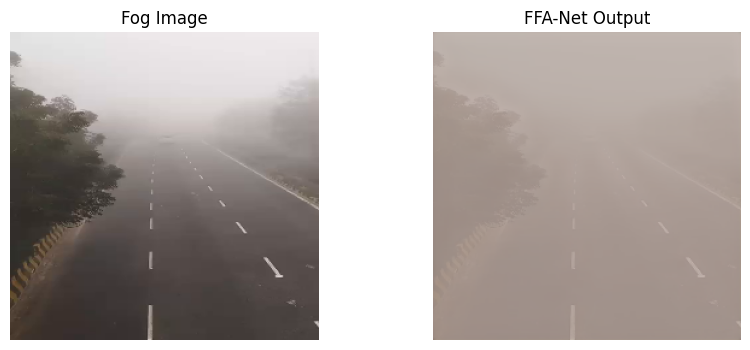

In [38]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Fog Image")
plt.imshow(fog)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("FFA-Net Output")
plt.imshow(dehaze)
plt.axis('off')

plt.show()

In [39]:
import shutil

shutil.make_archive("/content/outputs", 'zip', "/content/outputs")

'/content/outputs.zip'

In [41]:
import shutil

shutil.make_archive("/content/real_outputs", 'zip', "/content/real_outputs")

'/content/real_outputs.zip'

In [42]:
from google.colab import files

files.download("/content/real_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
import os
import cv2
import numpy as np

input_dir = "/content/real_frames/Dataset1"
output_dir = "/content/real_outputs/Dataset1"

sharp_in, sharp_out = [], []
contrast_in, contrast_out = [], []

input_files = sorted(os.listdir(input_dir))
output_files = sorted(os.listdir(output_dir))

for in_name, out_name in zip(input_files, output_files):

    in_path = os.path.join(input_dir, in_name)
    out_path = os.path.join(output_dir, out_name)

    inp = cv2.imread(in_path)
    out = cv2.imread(out_path)

    if inp is None or out is None:
        continue

    inp_gray = cv2.cvtColor(inp, cv2.COLOR_BGR2GRAY)
    out_gray = cv2.cvtColor(out, cv2.COLOR_BGR2GRAY)


    s_in = cv2.Laplacian(inp_gray, cv2.CV_64F).var()
    s_out = cv2.Laplacian(out_gray, cv2.CV_64F).var()


    c_in = inp_gray.std()
    c_out = out_gray.std()

    sharp_in.append(s_in)
    sharp_out.append(s_out)

    contrast_in.append(c_in)
    contrast_out.append(c_out)

print("Frames processed:", len(sharp_in))

print("Sharpness")
print("Input:", np.mean(sharp_in))
print("Output:", np.mean(sharp_out))
print("Improvement:", np.mean(sharp_out) - np.mean(sharp_in))

print("Contrast")
print("Input:", np.mean(contrast_in))
print("Output:", np.mean(contrast_out))
print("Improvement:", np.mean(contrast_out) - np.mean(contrast_in))

Frames processed: 325
Sharpness
Input: 429.77889681188964
Output: 19.31231749204704
Improvement: -410.4665793198426
Contrast
Input: 67.42969432763455
Output: 13.13074660377561
Improvement: -54.298947723858944
